In [3]:
# =========================
# 1. Установка библиотек
# =========================
!pip install lightautoml ydata-profiling

In [4]:
# =========================
# 2. Импорты
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from google.colab import files
import pickle

from lightautoml.automl.presets.tabular_presets import TabularAutoML
from lightautoml.tasks import Task

In [5]:
# =========================
# 3. Загрузка данных
# =========================
print("Загрузите файл:")
uploaded = files.upload()

for filename in uploaded.keys():
    file_path = filename

df = pd.read_csv(file_path)
print("Файл загружен!")
display(df.head())

Загрузите файл:


Saving hh ru DATASET.csv to hh ru DATASET (1).csv
Файл загружен!


,vacancy_id,employer_id,employees_number,creation_date,work_schedule,employment,length_of_employment,compensation_from,compensation_to,accept_teenagers,...,young_response_count,young_female_response_count,young_male_response_count,invitation_count,female_invitation_count,male_invitation_count,young_invitation_count,young_female_invitation_count,young_male_invitation_count,industry_id_list
0,77424192,2571258,300,2023-02-27,full_day,full,up_to_3_years,35000.0,0.0,False,...,4,4,0,21,21,0,0,0,0,[48]
1,78161908,4809555,50,2023-03-17,shift,full,no_experience,22500.0,NaN,False,...,5,4,1,26,26,0,2,2,0,[None]
2,79496395,5667513,5,2023-04-19,shift,full,up_to_3_years,24000.0,30000.0,False,...,2,2,0,3,3,0,0,0,0,[None]
3,87102246,1072323,0,2023-09-21,full_day,full,up_to_3_years,50000.0,NaN,False,...,0,0,0,9,7,2,0,0,0,"[7, 8]"
4,76367381,1160192,0,2023-01-30,full_day,full,up_to_3_years,55000.0,150000.0,False,...,0,0,0,49,39,10,0,0,0,"[5, 13]"


In [6]:
# =========================
# 4. Предобработка данных
# =========================
df['compensation_to_is_missing'] = df['compensation_to'].isna().astype(int)
df['compensation_to'] = df['compensation_to'].fillna(df['compensation_from'].median())
df['compensation_to'] = np.clip(df['compensation_to'], 0, 1500000)
df['response_count'] = np.clip(df['response_count'], 0, 1000)

df['employees_number'] = df['employees_number'].replace(0, np.nan)
df['employees_number'] = df['employees_number'].fillna(df['employees_number'].median())

sparse_cols = [
    'young_response_count',
    'young_female_response_count',
    'young_male_response_count',
    'young_invitation_count',
    'young_female_invitation_count',
    'young_male_invitation_count'
]

for col in sparse_cols:
    df[col + '_bin'] = (df[col] > 0).astype(int)

df['industry_count'] = df['industry_id_list'].apply(lambda x: len(str(x).split(',')))

df['creation_date'] = pd.to_datetime(df['creation_date'])
df['month'] = df['creation_date'].dt.month
df['day'] = df['creation_date'].dt.day
df['day_of_week'] = df['creation_date'].dt.weekday + 1
df = df.drop(columns=['creation_date'])

df['target'] = (df['invitation_count'] >= 10).astype(int)

# Удаляем утечки
drop_cols = [
    'invitation_count','female_invitation_count','male_invitation_count',
    'young_invitation_count','young_female_invitation_count','young_male_invitation_count',
    'young_response_count','young_female_response_count','young_male_response_count',
    'female_response_count','male_response_count','industry_id_list'
]
df = df.drop(columns=drop_cols)

df['salary_mean'] = (df['compensation_from'] + df['compensation_to']) / 2

In [7]:
# =========================
# 5. Заполнение пропусков
# =========================
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

cat_cols = df.select_dtypes(include=['object']).columns
for col in cat_cols:
    df[col] = df[col].fillna('missing')

In [8]:
# =========================
# 6. Train/Test split
# =========================
train, test = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['target']
)

In [9]:
# =========================
# 7. Функция для экспериментов
# =========================
def bootstrap_auc(preds, y, n_bootstraps=1000):
    rng = np.random.RandomState(42)
    aucs = []
    for i in range(n_bootstraps):
        idx = rng.randint(0, len(preds), len(preds))
        if len(np.unique(y.iloc[idx])) < 2:
            continue
        auc = roc_auc_score(y.iloc[idx], preds[idx])
        aucs.append(auc)
    return np.percentile(aucs, 2.5), np.percentile(aucs, 97.5)

def run_experiment(name, use_algos, timeout=600, add_features=None):
    print(f"\n=== Эксперимент: {name} ===")
    train_exp = train.copy()
    test_exp = test.copy()

    if add_features:
        for feat_name, feat_func in add_features.items():
            train_exp[feat_name] = feat_func(train_exp)
            test_exp[feat_name] = feat_func(test_exp)

    task = Task('binary')
    automl = TabularAutoML(
        task=task,
        timeout=timeout,
        general_params={'use_algos':[use_algos]}
    )

    oof_pred = automl.fit_predict(train_exp, roles={'target':'target'})
    test_pred = automl.predict(test_exp)

    auc = roc_auc_score(test_exp['target'], test_pred.data[:,0])
    low, high = bootstrap_auc(test_pred.data[:,0], test_exp['target'])

    print(f"AUC={auc:.3f}, 95% CI=({low:.3f},{high:.3f})")

    return {
        'name': name,
        'model': automl,
        'auc': auc,
        'ci_low': low,
        'ci_high': high,
        'pred': test_pred
    }

In [10]:
# =========================
# 8. Эксперименты
# =========================
results = []

# Эксперимент 1: базовый LGB
results.append(run_experiment("Base LGB", ['lgb', 'lgb_tuned'], timeout=600))

# Эксперимент 2: LGB + CatBoost
results.append(run_experiment("LGB + CatBoost", ['lgb', 'catboost'], timeout=900))

# Эксперимент 3: LGB_tuned + лог зарплаты
results.append(run_experiment("LGB_tuned + log_salary", ['lgb_tuned'], timeout=900,
                              add_features={'log_salary_mean': lambda df: np.log1p(df['salary_mean'])}))

INFO:lightautoml.automl.presets.base:Stdout logging level is ERROR.
INFO:lightautoml.automl.presets.base:Task: binary

INFO:lightautoml.automl.presets.base:Start automl preset with listed constraints:
INFO:lightautoml.automl.presets.base:- time: 600.00 seconds
INFO:lightautoml.automl.presets.base:- CPU: 4 cores
INFO:lightautoml.automl.presets.base:- memory: 16 GB

INFO:lightautoml.reader.base:Train data shape: (302212, 25)




=== Эксперимент: Base LGB ===


INFO3:lightautoml.reader.base:Feats was rejected during automatic roles guess: []
INFO:lightautoml.automl.base:Layer 1 train process start. Time left 586.50 secs
INFO3:lightautoml.ml_algo.boost_lgbm:Training until validation scores don't improve for 100 rounds
INFO3:lightautoml.ml_algo.boost_lgbm:[100]	valid's auc: 0.815477
INFO3:lightautoml.ml_algo.boost_lgbm:[200]	valid's auc: 0.820624
INFO3:lightautoml.ml_algo.boost_lgbm:[300]	valid's auc: 0.822711
INFO3:lightautoml.ml_algo.boost_lgbm:[400]	valid's auc: 0.824123
INFO3:lightautoml.ml_algo.boost_lgbm:[500]	valid's auc: 0.82502
INFO3:lightautoml.ml_algo.boost_lgbm:[600]	valid's auc: 0.825445
INFO3:lightautoml.ml_algo.boost_lgbm:[700]	valid's auc: 0.826036
INFO3:lightautoml.ml_algo.boost_lgbm:[800]	valid's auc: 0.826261
INFO3:lightautoml.ml_algo.boost_lgbm:[900]	valid's auc: 0.826379
INFO3:lightautoml.ml_algo.boost_lgbm:[1000]	valid's auc: 0.826484
INFO3:lightautoml.ml_algo.boost_lgbm:[1100]	valid's auc: 0.826503
INFO3:lightautoml.ml_al

AUC=0.836, 95% CI=(0.833,0.839)

=== Эксперимент: LGB + CatBoost ===


INFO3:lightautoml.reader.base:Feats was rejected during automatic roles guess: []
INFO:lightautoml.automl.base:Layer 1 train process start. Time left 887.53 secs
INFO3:lightautoml.ml_algo.boost_lgbm:Training until validation scores don't improve for 100 rounds
INFO3:lightautoml.ml_algo.boost_lgbm:[100]	valid's auc: 0.815477
INFO3:lightautoml.ml_algo.boost_lgbm:[200]	valid's auc: 0.820624
INFO3:lightautoml.ml_algo.boost_lgbm:[300]	valid's auc: 0.822711
INFO3:lightautoml.ml_algo.boost_lgbm:[400]	valid's auc: 0.824123
INFO3:lightautoml.ml_algo.boost_lgbm:[500]	valid's auc: 0.82502
INFO3:lightautoml.ml_algo.boost_lgbm:[600]	valid's auc: 0.825445
INFO3:lightautoml.ml_algo.boost_lgbm:[700]	valid's auc: 0.826036
INFO3:lightautoml.ml_algo.boost_lgbm:[800]	valid's auc: 0.826261
INFO3:lightautoml.ml_algo.boost_lgbm:[900]	valid's auc: 0.826379
INFO3:lightautoml.ml_algo.boost_lgbm:[1000]	valid's auc: 0.826484
INFO3:lightautoml.ml_algo.boost_lgbm:[1100]	valid's auc: 0.826503
INFO3:lightautoml.ml_al

AUC=0.835, 95% CI=(0.832,0.838)

=== Эксперимент: LGB_tuned + log_salary ===


INFO3:lightautoml.reader.base:Feats was rejected during automatic roles guess: []
INFO:lightautoml.automl.base:Layer 1 train process start. Time left 886.62 secs
INFO3:lightautoml.ml_algo.boost_lgbm:Training until validation scores don't improve for 100 rounds
INFO3:lightautoml.ml_algo.boost_lgbm:[100]	valid's auc: 0.815477
INFO3:lightautoml.ml_algo.boost_lgbm:[200]	valid's auc: 0.820624
INFO3:lightautoml.ml_algo.boost_lgbm:[300]	valid's auc: 0.822711
INFO3:lightautoml.ml_algo.boost_lgbm:[400]	valid's auc: 0.824123
INFO3:lightautoml.ml_algo.boost_lgbm:[500]	valid's auc: 0.82502
INFO3:lightautoml.ml_algo.boost_lgbm:[600]	valid's auc: 0.825446
INFO3:lightautoml.ml_algo.boost_lgbm:[700]	valid's auc: 0.826036
INFO3:lightautoml.ml_algo.boost_lgbm:[800]	valid's auc: 0.826261
INFO3:lightautoml.ml_algo.boost_lgbm:[900]	valid's auc: 0.826379
INFO3:lightautoml.ml_algo.boost_lgbm:[1000]	valid's auc: 0.826485
INFO3:lightautoml.ml_algo.boost_lgbm:[1100]	valid's auc: 0.826503
INFO3:lightautoml.ml_al

AUC=0.836, 95% CI=(0.833,0.839)


INFO:lightautoml.automl.presets.base:Stdout logging level is ERROR.
INFO:lightautoml.automl.presets.base:Task: binary

INFO:lightautoml.automl.presets.base:Start automl preset with listed constraints:
INFO:lightautoml.automl.presets.base:- time: 600.00 seconds
INFO:lightautoml.automl.presets.base:- CPU: 4 cores
INFO:lightautoml.automl.presets.base:- memory: 16 GB

INFO:lightautoml.reader.base:Train data shape: (302212, 25)


=== Эксперимент: Base LGB ===
INFO3:lightautoml.reader.base:Feats was rejected during automatic roles guess: []
INFO:lightautoml.automl.base:Layer 1 train process start. Time left 586.50 secs
INFO3:lightautoml.ml_algo.boost_lgbm:Training until validation scores don't improve for 100 rounds
INFO3:lightautoml.ml_algo.boost_lgbm:[100]	valid's auc: 0.815477
INFO3:lightautoml.ml_algo.boost_lgbm:[200]	valid's auc: 0.820624
INFO3:lightautoml.ml_algo.boost_lgbm:[300]	valid's auc: 0.822711
INFO3:lightautoml.ml_algo.boost_lgbm:[400]	valid's auc: 0.824123
INFO3:lightautoml.ml_algo.boost_lgbm:[500]	valid's auc: 0.82502
INFO3:lightautoml.ml_algo.boost_lgbm:[600]	valid's auc: 0.825445
INFO3:lightautoml.ml_algo.boost_lgbm:[700]	valid's auc: 0.826036
INFO3:lightautoml.ml_algo.boost_lgbm:[800]	valid's auc: 0.826261
INFO3:lightautoml.ml_algo.boost_lgbm:[900]	valid's auc: 0.826379
INFO3:lightautoml.ml_algo.boost_lgbm:[1000]	valid's auc: 0.826484
INFO3:lightautoml.ml_algo.boost_lgbm:[1100]	valid's auc: 0.826503
INFO3:lightautoml.ml_algo.boost_lgbm:[1200]	valid's auc: 0.82643
INFO3:lightautoml.ml_algo.boost_lgbm:Early stopping, best iteration is:
[1113]	valid's auc: 0.826571
INFO:lightautoml.ml_algo.base:Selector_LightGBM fitting and predicting completed
INFO:lightautoml.ml_algo.base:Start fitting Lvl_0_Pipe_0_Mod_0_LightGBM ...
DEBUG:lightautoml.ml_algo.base:Training params: {'task': 'train', 'learning_rate': 0.05, 'num_leaves': 244, 'feature_fraction': 0.7, 'bagging_fraction': 0.7, 'bagging_freq': 1, 'max_depth': -1, 'verbosity': -1, 'reg_alpha': 1, 'reg_lambda': 0.0, 'min_split_gain': 0.0, 'zero_as_missing': False, 'num_threads': 2, 'max_bin': 255, 'min_data_in_bin': 3, 'num_trees': 2000, 'early_stopping_rounds': 100, 'random_state': 42, 'verbose_eval': 100}
INFO2:lightautoml.ml_algo.base:===== Start working with fold 0 for Lvl_0_Pipe_0_Mod_0_LightGBM =====
INFO3:lightautoml.ml_algo.boost_lgbm:Training until validation scores don't improve for 100 rounds
INFO3:lightautoml.ml_algo.boost_lgbm:[100]	valid's auc: 0.829751
INFO3:lightautoml.ml_algo.boost_lgbm:[200]	valid's auc: 0.831365
INFO3:lightautoml.ml_algo.boost_lgbm:[300]	valid's auc: 0.831908
INFO3:lightautoml.ml_algo.boost_lgbm:[400]	valid's auc: 0.832119
INFO3:lightautoml.ml_algo.boost_lgbm:Early stopping, best iteration is:
[377]	valid's auc: 0.832201
INFO2:lightautoml.ml_algo.base:===== Start working with fold 1 for Lvl_0_Pipe_0_Mod_0_LightGBM =====
INFO3:lightautoml.ml_algo.boost_lgbm:Training until validation scores don't improve for 100 rounds
INFO3:lightautoml.ml_algo.boost_lgbm:[100]	valid's auc: 0.82454
INFO3:lightautoml.ml_algo.boost_lgbm:[200]	valid's auc: 0.825979
INFO3:lightautoml.ml_algo.boost_lgbm:[300]	valid's auc: 0.826407
INFO3:lightautoml.ml_algo.boost_lgbm:[400]	valid's auc: 0.826538
INFO3:lightautoml.ml_algo.boost_lgbm:[500]	valid's auc: 0.826534
INFO3:lightautoml.ml_algo.boost_lgbm:Early stopping, best iteration is:
[430]	valid's auc: 0.826689
INFO2:lightautoml.ml_algo.base:===== Start working with fold 2 for Lvl_0_Pipe_0_Mod_0_LightGBM =====
INFO3:lightautoml.ml_algo.boost_lgbm:Training until validation scores don't improve for 100 rounds
INFO3:lightautoml.ml_algo.boost_lgbm:[100]	valid's auc: 0.823965
INFO3:lightautoml.ml_algo.boost_lgbm:[200]	valid's auc: 0.826032
INFO3:lightautoml.ml_algo.boost_lgbm:[300]	valid's auc: 0.826294
INFO3:lightautoml.ml_algo.boost_lgbm:Early stopping, best iteration is:
[248]	valid's auc: 0.826505
INFO:lightautoml.ml_algo.base:Time limit exceeded after calculating fold 2

INFO:lightautoml.ml_algo.base:Fitting Lvl_0_Pipe_0_Mod_0_LightGBM finished. score = 0.8283261121115757
INFO:lightautoml.ml_algo.base:Lvl_0_Pipe_0_Mod_0_LightGBM fitting and predicting completed
INFO:lightautoml.ml_algo.tuning.optuna:Start hyperparameters optimization for Lvl_0_Pipe_0_Mod_1_Tuned_LightGBM ... Time budget is 1.00 secs
INFO:optuna.storages._in_memory:A new study created in memory with name: no-name-bdd5c342-0d4c-44f7-a451-2bab5dd62331
INFO3:lightautoml.ml_algo.boost_lgbm:Training until validation scores don't improve for 100 rounds
INFO3:lightautoml.ml_algo.boost_lgbm:[100]	valid's auc: 0.829627
INFO3:lightautoml.ml_algo.boost_lgbm:[200]	valid's auc: 0.832066
INFO3:lightautoml.ml_algo.boost_lgbm:[300]	valid's auc: 0.833244
INFO3:lightautoml.ml_algo.boost_lgbm:[400]	valid's auc: 0.833821
INFO3:lightautoml.ml_algo.boost_lgbm:[500]	valid's auc: 0.834144
INFO3:lightautoml.ml_algo.boost_lgbm:[600]	valid's auc: 0.834311
INFO3:lightautoml.ml_algo.boost_lgbm:[700]	valid's auc: 0.834334
INFO3:lightautoml.ml_algo.boost_lgbm:Early stopping, best iteration is:
[656]	valid's auc: 0.834401
INFO:optuna.study.study:Trial 0 finished with value: 0.8344005830152713 and parameters: {'feature_fraction': 0.6872700594236812, 'num_leaves': 244, 'bagging_fraction': 0.8659969709057025, 'min_sum_hessian_in_leaf': 0.24810409748678125, 'reg_alpha': 2.5361081166471375e-07, 'reg_lambda': 2.5348407664333426e-07}. Best is trial 0 with value: 0.8344005830152713.
INFO3:lightautoml.ml_algo.tuning.optuna:Trial 1 with hyperparameters {'feature_fraction': 0.6872700594236812, 'num_leaves': 244, 'bagging_fraction': 0.8659969709057025, 'min_sum_hessian_in_leaf': 0.24810409748678125, 'reg_alpha': 2.5361081166471375e-07, 'reg_lambda': 2.5348407664333426e-07} scored 0.8344005830152713 in 0:00:51.476202
INFO:lightautoml.ml_algo.tuning.optuna:Hyperparameters optimization for Lvl_0_Pipe_0_Mod_1_Tuned_LightGBM completed
INFO2:lightautoml.ml_algo.tuning.optuna:The set of hyperparameters {'feature_fraction': 0.6872700594236812, 'num_leaves': 244, 'bagging_fraction': 0.8659969709057025, 'min_sum_hessian_in_leaf': 0.24810409748678125, 'reg_alpha': 2.5361081166471375e-07, 'reg_lambda': 2.5348407664333426e-07}
 achieve 0.8344 auc
INFO:lightautoml.ml_algo.base:Start fitting Lvl_0_Pipe_0_Mod_1_Tuned_LightGBM ...
DEBUG:lightautoml.ml_algo.base:Training params: {'task': 'train', 'learning_rate': 0.05, 'num_leaves': 244, 'feature_fraction': 0.6872700594236812, 'bagging_fraction': 0.8659969709057025, 'bagging_freq': 1, 'max_depth': -1, 'verbosity': -1, 'reg_alpha': 2.5361081166471375e-07, 'reg_lambda': 2.5348407664333426e-07, 'min_split_gain': 0.0, 'zero_as_missing': False, 'num_threads': 2, 'max_bin': 255, 'min_data_in_bin': 3, 'num_trees': 3000, 'early_stopping_rounds': 100, 'random_state': 42, 'verbose_eval': 100, 'min_sum_hessian_in_leaf': 0.24810409748678125}
INFO2:lightautoml.ml_algo.base:===== Start working with fold 0 for Lvl_0_Pipe_0_Mod_1_Tuned_LightGBM =====
INFO3:lightautoml.ml_algo.boost_lgbm:Training until validation scores don't improve for 100 rounds
INFO3:lightautoml.ml_algo.boost_lgbm:[100]	valid's auc: 0.830315
INFO3:lightautoml.ml_algo.boost_lgbm:[200]	valid's auc: 0.832452
INFO3:lightautoml.ml_algo.boost_lgbm:[300]	valid's auc: 0.83302
INFO3:lightautoml.ml_algo.boost_lgbm:[400]	valid's auc: 0.833477
INFO3:lightautoml.ml_algo.boost_lgbm:[500]	valid's auc: 0.833399
INFO3:lightautoml.ml_algo.boost_lgbm:Early stopping, best iteration is:
[445]	valid's auc: 0.833502
INFO2:lightautoml.ml_algo.base:===== Start working with fold 1 for Lvl_0_Pipe_0_Mod_1_Tuned_LightGBM =====
INFO3:lightautoml.ml_algo.boost_lgbm:Training until validation scores don't improve for 100 rounds
INFO3:lightautoml.ml_algo.boost_lgbm:[100]	valid's auc: 0.824753
INFO3:lightautoml.ml_algo.boost_lgbm:[200]	valid's auc: 0.826085
INFO3:lightautoml.ml_algo.boost_lgbm:[300]	valid's auc: 0.826453
INFO3:lightautoml.ml_algo.boost_lgbm:[400]	valid's auc: 0.82663
INFO3:lightautoml.ml_algo.boost_lgbm:[500]	valid's auc: 0.82679
INFO3:lightautoml.ml_algo.boost_lgbm:[600]	valid's auc: 0.826725
INFO3:lightautoml.ml_algo.boost_lgbm:Early stopping, best iteration is:
[517]	valid's auc: 0.826884
INFO2:lightautoml.ml_algo.base:===== Start working with fold 2 for Lvl_0_Pipe_0_Mod_1_Tuned_LightGBM =====
INFO3:lightautoml.ml_algo.boost_lgbm:Training until validation scores don't improve for 100 rounds
INFO3:lightautoml.ml_algo.boost_lgbm:[100]	valid's auc: 0.824552
INFO3:lightautoml.ml_algo.boost_lgbm:[200]	valid's auc: 0.826162
INFO3:lightautoml.ml_algo.boost_lgbm:[300]	valid's auc: 0.826853
INFO3:lightautoml.ml_algo.boost_lgbm:[400]	valid's auc: 0.827224
INFO3:lightautoml.ml_algo.boost_lgbm:[500]	valid's auc: 0.827172
INFO3:lightautoml.ml_algo.boost_lgbm:[600]	valid's auc: 0.827214
INFO3:lightautoml.ml_algo.boost_lgbm:Early stopping, best iteration is:
[555]	valid's auc: 0.82737
INFO2:lightautoml.ml_algo.base:===== Start working with fold 3 for Lvl_0_Pipe_0_Mod_1_Tuned_LightGBM =====
INFO3:lightautoml.ml_algo.boost_lgbm:Training until validation scores don't improve for 100 rounds
INFO3:lightautoml.ml_algo.boost_lgbm:[100]	valid's auc: 0.827566
INFO3:lightautoml.ml_algo.boost_lgbm:[200]	valid's auc: 0.830033
INFO3:lightautoml.ml_algo.boost_lgbm:[300]	valid's auc: 0.830841
INFO3:lightautoml.ml_algo.boost_lgbm:[400]	valid's auc: 0.831251
INFO3:lightautoml.ml_algo.boost_lgbm:[500]	valid's auc: 0.831356
INFO3:lightautoml.ml_algo.boost_lgbm:[600]	valid's auc: 0.831554
INFO3:lightautoml.ml_algo.boost_lgbm:[700]	valid's auc: 0.831568
INFO3:lightautoml.ml_algo.boost_lgbm:Early stopping, best iteration is:
[655]	valid's auc: 0.831734
INFO2:lightautoml.ml_algo.base:===== Start working with fold 4 for Lvl_0_Pipe_0_Mod_1_Tuned_LightGBM =====
INFO3:lightautoml.ml_algo.boost_lgbm:Training until validation scores don't improve for 100 rounds
INFO3:lightautoml.ml_algo.boost_lgbm:[100]	valid's auc: 0.825898
INFO3:lightautoml.ml_algo.boost_lgbm:[200]	valid's auc: 0.827536
INFO3:lightautoml.ml_algo.boost_lgbm:[300]	valid's auc: 0.828076
INFO3:lightautoml.ml_algo.boost_lgbm:[400]	valid's auc: 0.82857
INFO3:lightautoml.ml_algo.boost_lgbm:[500]	valid's auc: 0.828728
INFO3:lightautoml.ml_algo.boost_lgbm:[600]	valid's auc: 0.828699
INFO3:lightautoml.ml_algo.boost_lgbm:Early stopping, best iteration is:
[527]	valid's auc: 0.828837
INFO:lightautoml.ml_algo.base:Fitting Lvl_0_Pipe_0_Mod_1_Tuned_LightGBM finished. score = 0.8295225170814541
INFO:lightautoml.ml_algo.base:Lvl_0_Pipe_0_Mod_1_Tuned_LightGBM fitting and predicting completed
INFO:lightautoml.automl.base:Time left 133.33 secs

INFO:lightautoml.automl.base:Time limit exceeded in one of the tasks. AutoML will blend level 1 models.

INFO:lightautoml.automl.base:Layer 1 training completed.

INFO:lightautoml.automl.blend:Blending: optimization starts with equal weights. Score = 0.8300340
INFO:lightautoml.automl.blend:Blending: iteration 0: score = 0.8300507, weights = [0.42455128 0.57544875]
INFO:lightautoml.automl.blend:Blending: no improvements for score. Terminated.

INFO:lightautoml.automl.blend:Blending: best score = 0.8300507, best weights = [0.42455128 0.57544875]
INFO:lightautoml.automl.presets.base:Automl preset training completed in 469.37 seconds

INFO:lightautoml.automl.presets.base:Model description:
Final prediction for new objects (level 0) =
	 0.42455 * (3 averaged models Lvl_0_Pipe_0_Mod_0_LightGBM) +
	 0.57545 * (5 averaged models Lvl_0_Pipe_0_Mod_1_Tuned_LightGBM)

INFO:lightautoml.automl.presets.base:Stdout logging level is ERROR.
INFO:lightautoml.automl.presets.base:Task: binary

INFO:lightautoml.automl.presets.base:Start automl preset with listed constraints:
INFO:lightautoml.automl.presets.base:- time: 900.00 seconds
INFO:lightautoml.automl.presets.base:- CPU: 4 cores
INFO:lightautoml.automl.presets.base:- memory: 16 GB

INFO:lightautoml.reader.base:Train data shape: (302212, 25)

AUC=0.836, 95% CI=(0.833,0.839)

=== Эксперимент: LGB + CatBoost ===
INFO3:lightautoml.reader.base:Feats was rejected during automatic roles guess: []
INFO:lightautoml.automl.base:Layer 1 train process start. Time left 887.53 secs
INFO3:lightautoml.ml_algo.boost_lgbm:Training until validation scores don't improve for 100 rounds
INFO3:lightautoml.ml_algo.boost_lgbm:[100]	valid's auc: 0.815477
INFO3:lightautoml.ml_algo.boost_lgbm:[200]	valid's auc: 0.820624
INFO3:lightautoml.ml_algo.boost_lgbm:[300]	valid's auc: 0.822711
INFO3:lightautoml.ml_algo.boost_lgbm:[400]	valid's auc: 0.824123
INFO3:lightautoml.ml_algo.boost_lgbm:[500]	valid's auc: 0.82502
INFO3:lightautoml.ml_algo.boost_lgbm:[600]	valid's auc: 0.825445
INFO3:lightautoml.ml_algo.boost_lgbm:[700]	valid's auc: 0.826036
INFO3:lightautoml.ml_algo.boost_lgbm:[800]	valid's auc: 0.826261
INFO3:lightautoml.ml_algo.boost_lgbm:[900]	valid's auc: 0.826379
INFO3:lightautoml.ml_algo.boost_lgbm:[1000]	valid's auc: 0.826484
INFO3:lightautoml.ml_algo.boost_lgbm:[1100]	valid's auc: 0.826503
INFO3:lightautoml.ml_algo.boost_lgbm:[1200]	valid's auc: 0.82643
INFO3:lightautoml.ml_algo.boost_lgbm:Early stopping, best iteration is:
[1113]	valid's auc: 0.826571
INFO:lightautoml.ml_algo.base:Selector_LightGBM fitting and predicting completed
INFO:lightautoml.ml_algo.base:Start fitting Lvl_0_Pipe_0_Mod_0_LightGBM ...
DEBUG:lightautoml.ml_algo.base:Training params: {'task': 'train', 'learning_rate': 0.05, 'num_leaves': 244, 'feature_fraction': 0.7, 'bagging_fraction': 0.7, 'bagging_freq': 1, 'max_depth': -1, 'verbosity': -1, 'reg_alpha': 1, 'reg_lambda': 0.0, 'min_split_gain': 0.0, 'zero_as_missing': False, 'num_threads': 2, 'max_bin': 255, 'min_data_in_bin': 3, 'num_trees': 2000, 'early_stopping_rounds': 100, 'random_state': 42, 'verbose_eval': 100}
INFO2:lightautoml.ml_algo.base:===== Start working with fold 0 for Lvl_0_Pipe_0_Mod_0_LightGBM =====
INFO3:lightautoml.ml_algo.boost_lgbm:Training until validation scores don't improve for 100 rounds
INFO3:lightautoml.ml_algo.boost_lgbm:[100]	valid's auc: 0.829751
INFO3:lightautoml.ml_algo.boost_lgbm:[200]	valid's auc: 0.831365
INFO3:lightautoml.ml_algo.boost_lgbm:[300]	valid's auc: 0.831908
INFO3:lightautoml.ml_algo.boost_lgbm:[400]	valid's auc: 0.832119
INFO3:lightautoml.ml_algo.boost_lgbm:Early stopping, best iteration is:
[377]	valid's auc: 0.832201
INFO2:lightautoml.ml_algo.base:===== Start working with fold 1 for Lvl_0_Pipe_0_Mod_0_LightGBM =====
INFO3:lightautoml.ml_algo.boost_lgbm:Training until validation scores don't improve for 100 rounds
INFO3:lightautoml.ml_algo.boost_lgbm:[100]	valid's auc: 0.82454
INFO3:lightautoml.ml_algo.boost_lgbm:[200]	valid's auc: 0.825979
INFO3:lightautoml.ml_algo.boost_lgbm:[300]	valid's auc: 0.826407
INFO3:lightautoml.ml_algo.boost_lgbm:[400]	valid's auc: 0.826538
INFO3:lightautoml.ml_algo.boost_lgbm:[500]	valid's auc: 0.826534
INFO3:lightautoml.ml_algo.boost_lgbm:Early stopping, best iteration is:
[430]	valid's auc: 0.826689
INFO2:lightautoml.ml_algo.base:===== Start working with fold 2 for Lvl_0_Pipe_0_Mod_0_LightGBM =====
INFO3:lightautoml.ml_algo.boost_lgbm:Training until validation scores don't improve for 100 rounds
INFO3:lightautoml.ml_algo.boost_lgbm:[100]	valid's auc: 0.823965
INFO3:lightautoml.ml_algo.boost_lgbm:[200]	valid's auc: 0.826032
INFO3:lightautoml.ml_algo.boost_lgbm:[300]	valid's auc: 0.826294
INFO3:lightautoml.ml_algo.boost_lgbm:Early stopping, best iteration is:
[248]	valid's auc: 0.826505
INFO2:lightautoml.ml_algo.base:===== Start working with fold 3 for Lvl_0_Pipe_0_Mod_0_LightGBM =====
INFO3:lightautoml.ml_algo.boost_lgbm:Training until validation scores don't improve for 100 rounds
INFO3:lightautoml.ml_algo.boost_lgbm:[100]	valid's auc: 0.82818
INFO3:lightautoml.ml_algo.boost_lgbm:[200]	valid's auc: 0.830255
INFO3:lightautoml.ml_algo.boost_lgbm:[300]	valid's auc: 0.830923
INFO3:lightautoml.ml_algo.boost_lgbm:[400]	valid's auc: 0.831224
INFO3:lightautoml.ml_algo.boost_lgbm:[500]	valid's auc: 0.831073
INFO3:lightautoml.ml_algo.boost_lgbm:Early stopping, best iteration is:
[412]	valid's auc: 0.831246
INFO2:lightautoml.ml_algo.base:===== Start working with fold 4 for Lvl_0_Pipe_0_Mod_0_LightGBM =====
INFO3:lightautoml.ml_algo.boost_lgbm:Training until validation scores don't improve for 100 rounds
INFO3:lightautoml.ml_algo.boost_lgbm:[100]	valid's auc: 0.825337
INFO3:lightautoml.ml_algo.boost_lgbm:[200]	valid's auc: 0.827386
INFO3:lightautoml.ml_algo.boost_lgbm:[300]	valid's auc: 0.828039
INFO3:lightautoml.ml_algo.boost_lgbm:[400]	valid's auc: 0.828347
INFO3:lightautoml.ml_algo.boost_lgbm:[500]	valid's auc: 0.828255
INFO3:lightautoml.ml_algo.boost_lgbm:Early stopping, best iteration is:
[440]	valid's auc: 0.828394
INFO:lightautoml.ml_algo.base:Fitting Lvl_0_Pipe_0_Mod_0_LightGBM finished. score = 0.8289061630824792
INFO:lightautoml.ml_algo.base:Lvl_0_Pipe_0_Mod_0_LightGBM fitting and predicting completed
INFO:lightautoml.automl.base:Time left 627.29 secs

INFO:lightautoml.automl.base:Layer 1 training completed.

INFO:lightautoml.automl.presets.base:Automl preset training completed in 272.72 seconds

INFO:lightautoml.automl.presets.base:Model description:
Final prediction for new objects (level 0) =
	 1.00000 * (5 averaged models Lvl_0_Pipe_0_Mod_0_LightGBM)

INFO:lightautoml.automl.presets.base:Stdout logging level is ERROR.
INFO:lightautoml.automl.presets.base:Task: binary

INFO:lightautoml.automl.presets.base:Start automl preset with listed constraints:
INFO:lightautoml.automl.presets.base:- time: 900.00 seconds
INFO:lightautoml.automl.presets.base:- CPU: 4 cores
INFO:lightautoml.automl.presets.base:- memory: 16 GB

INFO:lightautoml.reader.base:Train data shape: (302212, 26)

AUC=0.835, 95% CI=(0.832,0.838)

=== Эксперимент: LGB_tuned + log_salary ===
INFO3:lightautoml.reader.base:Feats was rejected during automatic roles guess: []
INFO:lightautoml.automl.base:Layer 1 train process start. Time left 886.62 secs
INFO3:lightautoml.ml_algo.boost_lgbm:Training until validation scores don't improve for 100 rounds
INFO3:lightautoml.ml_algo.boost_lgbm:[100]	valid's auc: 0.815477
INFO3:lightautoml.ml_algo.boost_lgbm:[200]	valid's auc: 0.820624
INFO3:lightautoml.ml_algo.boost_lgbm:[300]	valid's auc: 0.822711
INFO3:lightautoml.ml_algo.boost_lgbm:[400]	valid's auc: 0.824123
INFO3:lightautoml.ml_algo.boost_lgbm:[500]	valid's auc: 0.82502
INFO3:lightautoml.ml_algo.boost_lgbm:[600]	valid's auc: 0.825446
INFO3:lightautoml.ml_algo.boost_lgbm:[700]	valid's auc: 0.826036
INFO3:lightautoml.ml_algo.boost_lgbm:[800]	valid's auc: 0.826261
INFO3:lightautoml.ml_algo.boost_lgbm:[900]	valid's auc: 0.826379
INFO3:lightautoml.ml_algo.boost_lgbm:[1000]	valid's auc: 0.826485
INFO3:lightautoml.ml_algo.boost_lgbm:[1100]	valid's auc: 0.826503
INFO3:lightautoml.ml_algo.boost_lgbm:[1200]	valid's auc: 0.82643
INFO3:lightautoml.ml_algo.boost_lgbm:Early stopping, best iteration is:
[1113]	valid's auc: 0.826572
INFO:lightautoml.ml_algo.base:Selector_LightGBM fitting and predicting completed
INFO:lightautoml.ml_algo.tuning.optuna:Start hyperparameters optimization for Lvl_0_Pipe_0_Mod_0_Tuned_LightGBM ... Time budget is 1.00 secs
INFO:optuna.storages._in_memory:A new study created in memory with name: no-name-e0d3f562-3f38-4b50-af0d-e04f0a259edc
INFO3:lightautoml.ml_algo.boost_lgbm:Training until validation scores don't improve for 100 rounds
INFO3:lightautoml.ml_algo.boost_lgbm:[100]	valid's auc: 0.829129
INFO3:lightautoml.ml_algo.boost_lgbm:[200]	valid's auc: 0.831978
INFO3:lightautoml.ml_algo.boost_lgbm:[300]	valid's auc: 0.832758
INFO3:lightautoml.ml_algo.boost_lgbm:[400]	valid's auc: 0.833183
INFO3:lightautoml.ml_algo.boost_lgbm:[500]	valid's auc: 0.833666
INFO3:lightautoml.ml_algo.boost_lgbm:[600]	valid's auc: 0.833935
INFO3:lightautoml.ml_algo.boost_lgbm:[700]	valid's auc: 0.834015
INFO3:lightautoml.ml_algo.boost_lgbm:[800]	valid's auc: 0.834155
INFO3:lightautoml.ml_algo.boost_lgbm:[900]	valid's auc: 0.834091
INFO3:lightautoml.ml_algo.boost_lgbm:Early stopping, best iteration is:
[857]	valid's auc: 0.83421
INFO:optuna.study.study:Trial 0 finished with value: 0.8342104718293724 and parameters: {'feature_fraction': 0.6872700594236812, 'num_leaves': 244, 'bagging_fraction': 0.8659969709057025, 'min_sum_hessian_in_leaf': 0.24810409748678125, 'reg_alpha': 2.5361081166471375e-07, 'reg_lambda': 2.5348407664333426e-07}. Best is trial 0 with value: 0.8342104718293724.
INFO3:lightautoml.ml_algo.tuning.optuna:Trial 1 with hyperparameters {'feature_fraction': 0.6872700594236812, 'num_leaves': 244, 'bagging_fraction': 0.8659969709057025, 'min_sum_hessian_in_leaf': 0.24810409748678125, 'reg_alpha': 2.5361081166471375e-07, 'reg_lambda': 2.5348407664333426e-07} scored 0.8342104718293724 in 0:01:04.674727
INFO:lightautoml.ml_algo.tuning.optuna:Hyperparameters optimization for Lvl_0_Pipe_0_Mod_0_Tuned_LightGBM completed
INFO2:lightautoml.ml_algo.tuning.optuna:The set of hyperparameters {'feature_fraction': 0.6872700594236812, 'num_leaves': 244, 'bagging_fraction': 0.8659969709057025, 'min_sum_hessian_in_leaf': 0.24810409748678125, 'reg_alpha': 2.5361081166471375e-07, 'reg_lambda': 2.5348407664333426e-07}
 achieve 0.8342 auc
INFO:lightautoml.ml_algo.base:Start fitting Lvl_0_Pipe_0_Mod_0_Tuned_LightGBM ...
DEBUG:lightautoml.ml_algo.base:Training params: {'task': 'train', 'learning_rate': 0.05, 'num_leaves': 244, 'feature_fraction': 0.6872700594236812, 'bagging_fraction': 0.8659969709057025, 'bagging_freq': 1, 'max_depth': -1, 'verbosity': -1, 'reg_alpha': 2.5361081166471375e-07, 'reg_lambda': 2.5348407664333426e-07, 'min_split_gain': 0.0, 'zero_as_missing': False, 'num_threads': 2, 'max_bin': 255, 'min_data_in_bin': 3, 'num_trees': 3000, 'early_stopping_rounds': 100, 'random_state': 42, 'verbose_eval': 100, 'min_sum_hessian_in_leaf': 0.24810409748678125}
INFO2:lightautoml.ml_algo.base:===== Start working with fold 0 for Lvl_0_Pipe_0_Mod_0_Tuned_LightGBM =====
INFO3:lightautoml.ml_algo.boost_lgbm:Training until validation scores don't improve for 100 rounds
INFO3:lightautoml.ml_algo.boost_lgbm:[100]	valid's auc: 0.830156
INFO3:lightautoml.ml_algo.boost_lgbm:[200]	valid's auc: 0.832385
INFO3:lightautoml.ml_algo.boost_lgbm:[300]	valid's auc: 0.832941
INFO3:lightautoml.ml_algo.boost_lgbm:[400]	valid's auc: 0.833375
INFO3:lightautoml.ml_algo.boost_lgbm:[500]	valid's auc: 0.83355
INFO3:lightautoml.ml_algo.boost_lgbm:Early stopping, best iteration is:
[481]	valid's auc: 0.833632
INFO2:lightautoml.ml_algo.base:===== Start working with fold 1 for Lvl_0_Pipe_0_Mod_0_Tuned_LightGBM =====
INFO3:lightautoml.ml_algo.boost_lgbm:Training until validation scores don't improve for 100 rounds
INFO3:lightautoml.ml_algo.boost_lgbm:[100]	valid's auc: 0.824563
INFO3:lightautoml.ml_algo.boost_lgbm:[200]	valid's auc: 0.826144
INFO3:lightautoml.ml_algo.boost_lgbm:[300]	valid's auc: 0.826764
INFO3:lightautoml.ml_algo.boost_lgbm:[400]	valid's auc: 0.827063
INFO3:lightautoml.ml_algo.boost_lgbm:[500]	valid's auc: 0.827082
INFO3:lightautoml.ml_algo.boost_lgbm:[600]	valid's auc: 0.827082
INFO3:lightautoml.ml_algo.boost_lgbm:Early stopping, best iteration is:
[523]	valid's auc: 0.827231
INFO2:lightautoml.ml_algo.base:===== Start working with fold 2 for Lvl_0_Pipe_0_Mod_0_Tuned_LightGBM =====
INFO3:lightautoml.ml_algo.boost_lgbm:Training until validation scores don't improve for 100 rounds
INFO3:lightautoml.ml_algo.boost_lgbm:[100]	valid's auc: 0.824132
INFO3:lightautoml.ml_algo.boost_lgbm:[200]	valid's auc: 0.826486
INFO3:lightautoml.ml_algo.boost_lgbm:[300]	valid's auc: 0.827091
INFO3:lightautoml.ml_algo.boost_lgbm:[400]	valid's auc: 0.827227
INFO3:lightautoml.ml_algo.boost_lgbm:Early stopping, best iteration is:
[373]	valid's auc: 0.827317
INFO2:lightautoml.ml_algo.base:===== Start working with fold 3 for Lvl_0_Pipe_0_Mod_0_Tuned_LightGBM =====
INFO3:lightautoml.ml_algo.boost_lgbm:Training until validation scores don't improve for 100 rounds
INFO3:lightautoml.ml_algo.boost_lgbm:[100]	valid's auc: 0.827766
INFO3:lightautoml.ml_algo.boost_lgbm:[200]	valid's auc: 0.830145
INFO3:lightautoml.ml_algo.boost_lgbm:[300]	valid's auc: 0.830764
INFO3:lightautoml.ml_algo.boost_lgbm:[400]	valid's auc: 0.831335
INFO3:lightautoml.ml_algo.boost_lgbm:[500]	valid's auc: 0.83159
INFO3:lightautoml.ml_algo.boost_lgbm:[600]	valid's auc: 0.831526
INFO3:lightautoml.ml_algo.boost_lgbm:Early stopping, best iteration is:
[505]	valid's auc: 0.831621
INFO2:lightautoml.ml_algo.base:===== Start working with fold 4 for Lvl_0_Pipe_0_Mod_0_Tuned_LightGBM =====
INFO3:lightautoml.ml_algo.boost_lgbm:Training until validation scores don't improve for 100 rounds
INFO3:lightautoml.ml_algo.boost_lgbm:[100]	valid's auc: 0.825618
INFO3:lightautoml.ml_algo.boost_lgbm:[200]	valid's auc: 0.827468
INFO3:lightautoml.ml_algo.boost_lgbm:[300]	valid's auc: 0.82825
INFO3:lightautoml.ml_algo.boost_lgbm:[400]	valid's auc: 0.82886
INFO3:lightautoml.ml_algo.boost_lgbm:[500]	valid's auc: 0.828972
INFO3:lightautoml.ml_algo.boost_lgbm:Early stopping, best iteration is:
[493]	valid's auc: 0.829027
INFO:lightautoml.ml_algo.base:Fitting Lvl_0_Pipe_0_Mod_0_Tuned_LightGBM finished. score = 0.8296502449112382
INFO:lightautoml.ml_algo.base:Lvl_0_Pipe_0_Mod_0_Tuned_LightGBM fitting and predicting completed
INFO:lightautoml.automl.base:Time left 547.72 secs

INFO:lightautoml.automl.base:Layer 1 training completed.

INFO:lightautoml.automl.presets.base:Automl preset training completed in 352.29 seconds

INFO:lightautoml.automl.presets.base:Model description:
Final prediction for new objects (level 0) =
	 1.00000 * (5 averaged models Lvl_0_Pipe_0_Mod_0_Tuned_LightGBM)

AUC=0.836, 95% CI=(0.833,0.839)


In [11]:
# =========================
# 9. Выбор лучшей модели
# =========================
best_model = max(results, key=lambda x: x['auc'])
print(f"\n=== Лучшая модель: {best_model['name']} (AUC={best_model['auc']:.3f}) ===")


=== Лучшая модель: Base LGB (AUC=0.836) ===



=== Лучшая модель: Base LGB (AUC=0.836) ===


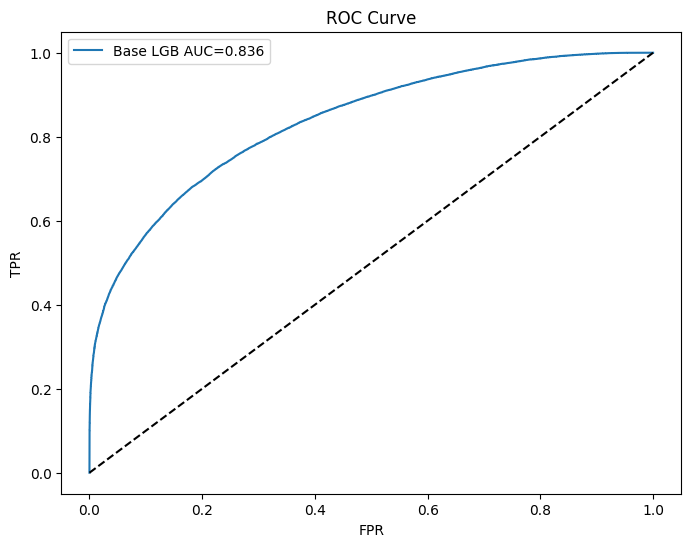

In [12]:
# =========================
# 10. ROC кривая лучшей модели
# =========================
fpr, tpr, _ = roc_curve(test['target'], best_model['pred'].data[:,0])
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"{best_model['name']} AUC={best_model['auc']:.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [16]:
# =========================
# 11. Feature Importance
# =========================

importance = best_model['model'].get_feature_scores()

# Проверяем названия колонок
print("Columns in feature importance DataFrame:", importance.columns)

# Сортируем по колонке 'Importance'
importance_sorted = importance.sort_values(by='Importance', ascending=False)

# Показываем топ-20 признаков
display(importance_sorted.head(10))


Columns in feature importance DataFrame: Index(['Feature', 'Importance'], dtype='object')


,Feature,Importance
0,response_count,457336.598021
1,young_invitation_count_bin,193430.960505
2,employer_id,141999.197096
3,employees_number,114642.353225
4,vacancy_id,83281.811777
5,compensation_from,72676.214794
6,salary_mean,70659.466313
7,day,52299.697341
8,compensation_to,50025.454524
9,young_response_count_bin,29673.025751


In [19]:
# HTML-отчет LightAutoML
import pandas as pd
import matplotlib.pyplot as plt
from ydata_profiling import ProfileReport
from sklearn.metrics import roc_auc_score, roc_curve

# 1. Добавляем предсказания к тестовому набору
report_df = test.copy()
report_df['pred_prob'] = best_model['pred'].data[:,0]

# 2. Вычисляем AUC
auc_score = roc_auc_score(report_df['target'], report_df['pred_prob'])
print(f"AUC на тесте: {auc_score:.3f}")

# 3. ROC-кривая
fpr, tpr, _ = roc_curve(report_df['target'], report_df['pred_prob'])
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'AUC={auc_score:.3f}')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.title('ROC Curve')
plt.legend()
plt.savefig("roc_curve.png")  # сохраняем график
plt.close()

# 4. Feature importance
importance = best_model['model'].get_feature_scores()
importance_sorted = importance.sort_values(by='Importance', ascending=False)
importance_sorted.to_csv("feature_importance.csv", index=False)

# 5. Генерируем HTML-отчет через ydata-profiling
profile = ProfileReport(
    report_df,
    title=f"LightAutoML Report - {best_model['name']}",
    explorative=True
)

profile.to_file("lightautoml_report.html")
print("HTML-отчет LightAutoML сохранен в 'lightautoml_report.html'")

AUC на тесте: 0.836


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 26/26 [00:03<00:00,  7.46it/s]
/usr/local/lib/python3.12/dist-packages/ydata_profiling/model/pandas/discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[2 0 9 ... 4 5 6]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(
/usr/local/lib/python3.12/dist-packages/ydata_profiling/model/pandas/discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[7 6 6 ... 6 4 0]' has dtype incompatible with int32, please explicitly cast to a compatible dtype first.
  discretized_df.loc[:, column] = self._discretize_column(
/usr/local/lib/python3.12/dist-packages/ydata_profiling/model/pandas/discretize_pandas.py:52: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of 

Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

HTML-отчет LightAutoML сохранен в 'lightautoml_report.html'


In [20]:

# =========================
# 12. Сохранение лучшей модели
# =========================
with open('best_automl_model.pkl','wb') as f:
    pickle.dump(best_model['model'], f)
print("Лучшая модель сохранена!")

Лучшая модель сохранена!


In [21]:
# =========================
# 13. Инференс 1 записи
# =========================
sample = test.drop(columns=['target']).iloc[[0]].copy()
pred = best_model['model'].predict(sample)
proba = pred.data[0][0]
print(f"Вероятность получения приглашения: {proba:.3f}")

Вероятность получения приглашения: 0.187


Были реализованы два подхода: традиционный и AutoML. Традиционный подход позволил глубже понять структуру данных и влияние признаков на модель, однако требовал значительных временных затрат и ручной настройки.

Использование LightAutoML позволило автоматизировать процесс построения модели, включая выбор алгоритмов и настройку гиперпараметров, при этом достигнув сопоставимого или более высокого качества (ROC-AUC).

Таким образом, AutoML является эффективным инструментом для быстрого получения качественных решений, в то время как традиционный подход обеспечивает лучший контроль и интерпретируемость модели.